# Exp4 Proxy Sufficiency Impossibility Result Check

Rendered result check with CSV previews and embedded PNG figures. This notebook reads existing outputs only and is safe to run from either the repository root or the `ipy/` directory.

In [5]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Markdown, Image


def find_project_root():
    for base in (Path.cwd(), *Path.cwd().parents):
        if (
            (base / 'README.md').is_file()
            and (base / 'requirements.txt').is_file()
            and (base / 'outputs').exists()
            and (base / 'ipy' / 'exp4_result_check.ipynb').is_file()
        ):
            return base.resolve()
    raise FileNotFoundError('Could not locate the project root. Start Jupyter from this repository or its ipy/ directory.')


ROOT = find_project_root()
PROJECT = ROOT.name


def rel(path):
    return path.resolve().relative_to(ROOT).as_posix()


def find_files(patterns):
    out = []
    for pattern in patterns:
        out.extend(ROOT.glob(pattern))
    return sorted({p for p in out if p.is_file()})


def run_dir(path):
    parts = path.relative_to(ROOT).parts
    if len(parts) >= 3 and parts[0] == 'outputs' and parts[1] == 'runs':
        return ROOT / parts[0] / parts[1] / parts[2]
    return None


def latest_run_key(path):
    rdir = run_dir(path)
    if rdir is None:
        return 0.0
    return rdir.stat().st_mtime


def prefer_outputs(paths):
    def score(path):
        s = path.as_posix().lower()
        value = 0
        if '/outputs/runs/' in s:
            value -= 200
        if 'full_' in s or 'exp4_full' in s:
            value -= 100
        if 'fast_' in s or 'fast_pipeline' in s:
            value -= 50
        if 'code_check_smoke' in s:
            value += 200
        if '/figures/png/' in s:
            value -= 10
        return (value, -latest_run_key(path), s)
    return sorted(paths, key=score)


def show_dataframe(path, rows=8):
    display(Markdown(f'**{rel(path)}**'))
    try:
        df = pd.read_csv(path)
        display(df.head(rows))
        display(Markdown(f'Rows: `{len(df)}` | Columns: `{len(df.columns)}`'))
    except Exception as exc:
        display(Markdown(f'Warning: could not read `{rel(path)}`: `{type(exc).__name__}: {exc}`'))


def show_images(paths, limit=4):
    if not paths:
        display(Markdown('Warning: no PNG figures found.'))
        return
    for path in paths[:limit]:
        display(Markdown(f'**{rel(path)}**'))
        display(Image(filename=str(path)))


display(Markdown(f'Project root: `{ROOT}`'))

Project root: `D:\research\CausalRegretMinimizationUnderDelayedFeedback\experiment\github\exp4_proxy_sufficiency_impossibility`

In [6]:
required_paths = ['README.md', 'requirements.txt', 'reproduce_all.py', 'code_check.py', 'self_check.py', 'outputs', 'runlogs']
optional_paths = ['input', 'docs']
rows = []
for name in required_paths + optional_paths:
    rows.append({'path': name, 'required': name in required_paths, 'exists': (ROOT / name).exists()})

display(pd.DataFrame(rows))
missing = [row['path'] for row in rows if row['required'] and not row['exists']]
if missing:
    display(Markdown('Warning: required GitHub-facing paths missing: ' + ', '.join(missing)))
else:
    display(Markdown('Required GitHub-facing paths are present.'))

,path,required,exists
0,README.md,True,True
1,requirements.txt,True,True
2,reproduce_all.py,True,True
3,code_check.py,True,True
4,self_check.py,True,True
5,outputs,True,True
6,runlogs,True,True
7,input,False,True
8,docs,False,False


Required GitHub-facing paths are present.

In [7]:
csvs = prefer_outputs(find_files([
    'outputs/**/summaries/*.csv',
    'outputs/**/summary/*.csv',
    'outputs/**/tables/*.csv',
    'outputs/**/checks/*.csv',
    'outputs/**/figures/metadata/*.csv',
    'outputs/**/metadata/*.csv',
]))

display(Markdown(f'Found `{len(csvs)}` CSV/table/check/metadata files. Showing selected previews.'))
for path in csvs[:6]:
    show_dataframe(path)

Found `23` CSV/table/check/metadata files. Showing selected previews.

**outputs/runs/full_20260624T060105Z_02caa92e/checks/exp4_code_check_report.csv**

,check_name,status,details
0,standalone entry point,PASSED,static code check
1,canonical reproduce-all entry point,PASSED,static code check
2,no external common package dependency,PASSED,static code check
3,all required scripts present,PASSED,static code check
4,redundant reproduction wrappers and package st...,PASSED,static code check
5,"no obsolete method, figure, or pseudo-p-value ...",PASSED,static code check
6,"method registry separates deployable, referenc...",PASSED,static code check
7,observable history metadata matches arrival-fe...,PASSED,static code check


Rows: `14` | Columns: `3`

**outputs/runs/full_20260624T060105Z_02caa92e/checks/exp4_self_check_report.csv**

...

,subexperiment_id,setting_id,delay_state_coupling_beta,notes,experiment_id,seed,source_label_rate_q,proxy_noise_sigma,causal_regret_per_round,causal_regret_all_rounds,...,method_display_name,information_interface,reference_role,diagnostic_only,deployable,mean_delay,pending_at_horizon,pending_fraction,source_state_mismatch,ranking_reversal_rate
0,baseline_reference,arrival_time_baseline,2.0,NaN,exp4_recoverability_boundary,0,0.0,0.25,0.617180,0.617261,...,Arrival time,arrival_time,none,False,True,2.0,6,0.0012,0.309965,0.164397
1,baseline_reference,arrival_time_baseline,2.0,NaN,exp4_recoverability_boundary,1,0.0,0.25,0.613236,0.615540,...,Arrival time,arrival_time,none,False,True,2.0,6,0.0012,0.304566,0.164598
2,baseline_reference,arrival_time_baseline,2.0,NaN,exp4_recoverability_boundary,2,0.0,0.25,0.587483,0.587940,...,Arrival time,arrival_time,none,False,True,2.0,6,0.0012,0.317172,0.169604
3,baseline_reference,arrival_time_baseline,2.0,NaN,exp4_recoverability_boundary,3,0.0,0.25,0.598626,0.604005,...,Arrival time,arrival_time,none,False,True,2.0,6,0.0012,0.314402,0.167601
4,baseline_reference,arrival_time_baseline,2.0,NaN,exp4_recoverability_boundary,4,0.0,0.25,0.616494,0.617624,...,Arrival time,arrival_time,none,False,True,2.0,6,0.0012,0.310411,0.168803
5,baseline_reference,arrival_time_baseline,2.0,NaN,exp4_recoverability_boundary,5,0.0,0.25,0.610690,0.611715,...,Arrival time,arrival_time,none,False,True,2.0,4,0.0008,0.309882,0.166533
6,baseline_reference,arrival_time_baseline,2.0,NaN,exp4_recoverability_boundary,6,0.0,0.25,0.571788,0.576223,...,Arrival time,arrival_time,none,False,True,2.0,6,0.0012,0.291575,0.165398
7,baseline_reference,arrival_time_baseline,2.0,NaN,exp4_recoverability_boundary,7,0.0,0.25,0.636779,0.634938,...,Arrival time,arrival_time,none,False,True,2.0,5,0.0010,0.302030,0.166967


Rows: `2340` | Columns: `35`

**outputs/runs/full_20260624T060105Z_02caa92e/summaries/metric_specification.csv**

,metric_id,metric_formula_id,formula
0,causal_regret_per_round,post_warmup_structural_regret,"mean_{t=warmup_t+1..T}[ell(A_t,S_t)-min_a ell(..."
1,proxy_state_error_per_round,mean_l2_proxy_state_error,mean_t ||P_t-S_t||_2; environment-side diagnostic
2,absolute_proxy_distortion_per_round,mean_absolute_loss_map_difference,"mean_{t,a}|ell(a,S_t)-ell(a,P_t)|; environment..."
3,oracle_normalized_recovery,arrival_oracle_normalized_recovery,(R_arrival-R_route)/(R_arrival-R_proxy_oracle)...
4,source_labelled_normalized_recovery,arrival_source_labelled_normalized_recovery,(R_arrival-R_route)/(R_arrival-R_source_labell...


Rows: `5` | Columns: `3`

Found `2` PNG figure files. Showing selected embedded figures.

**outputs/runs/full_20260624T060105Z_02caa92e/figures/png/fig_app_exp4_delay_state_coupling.png**

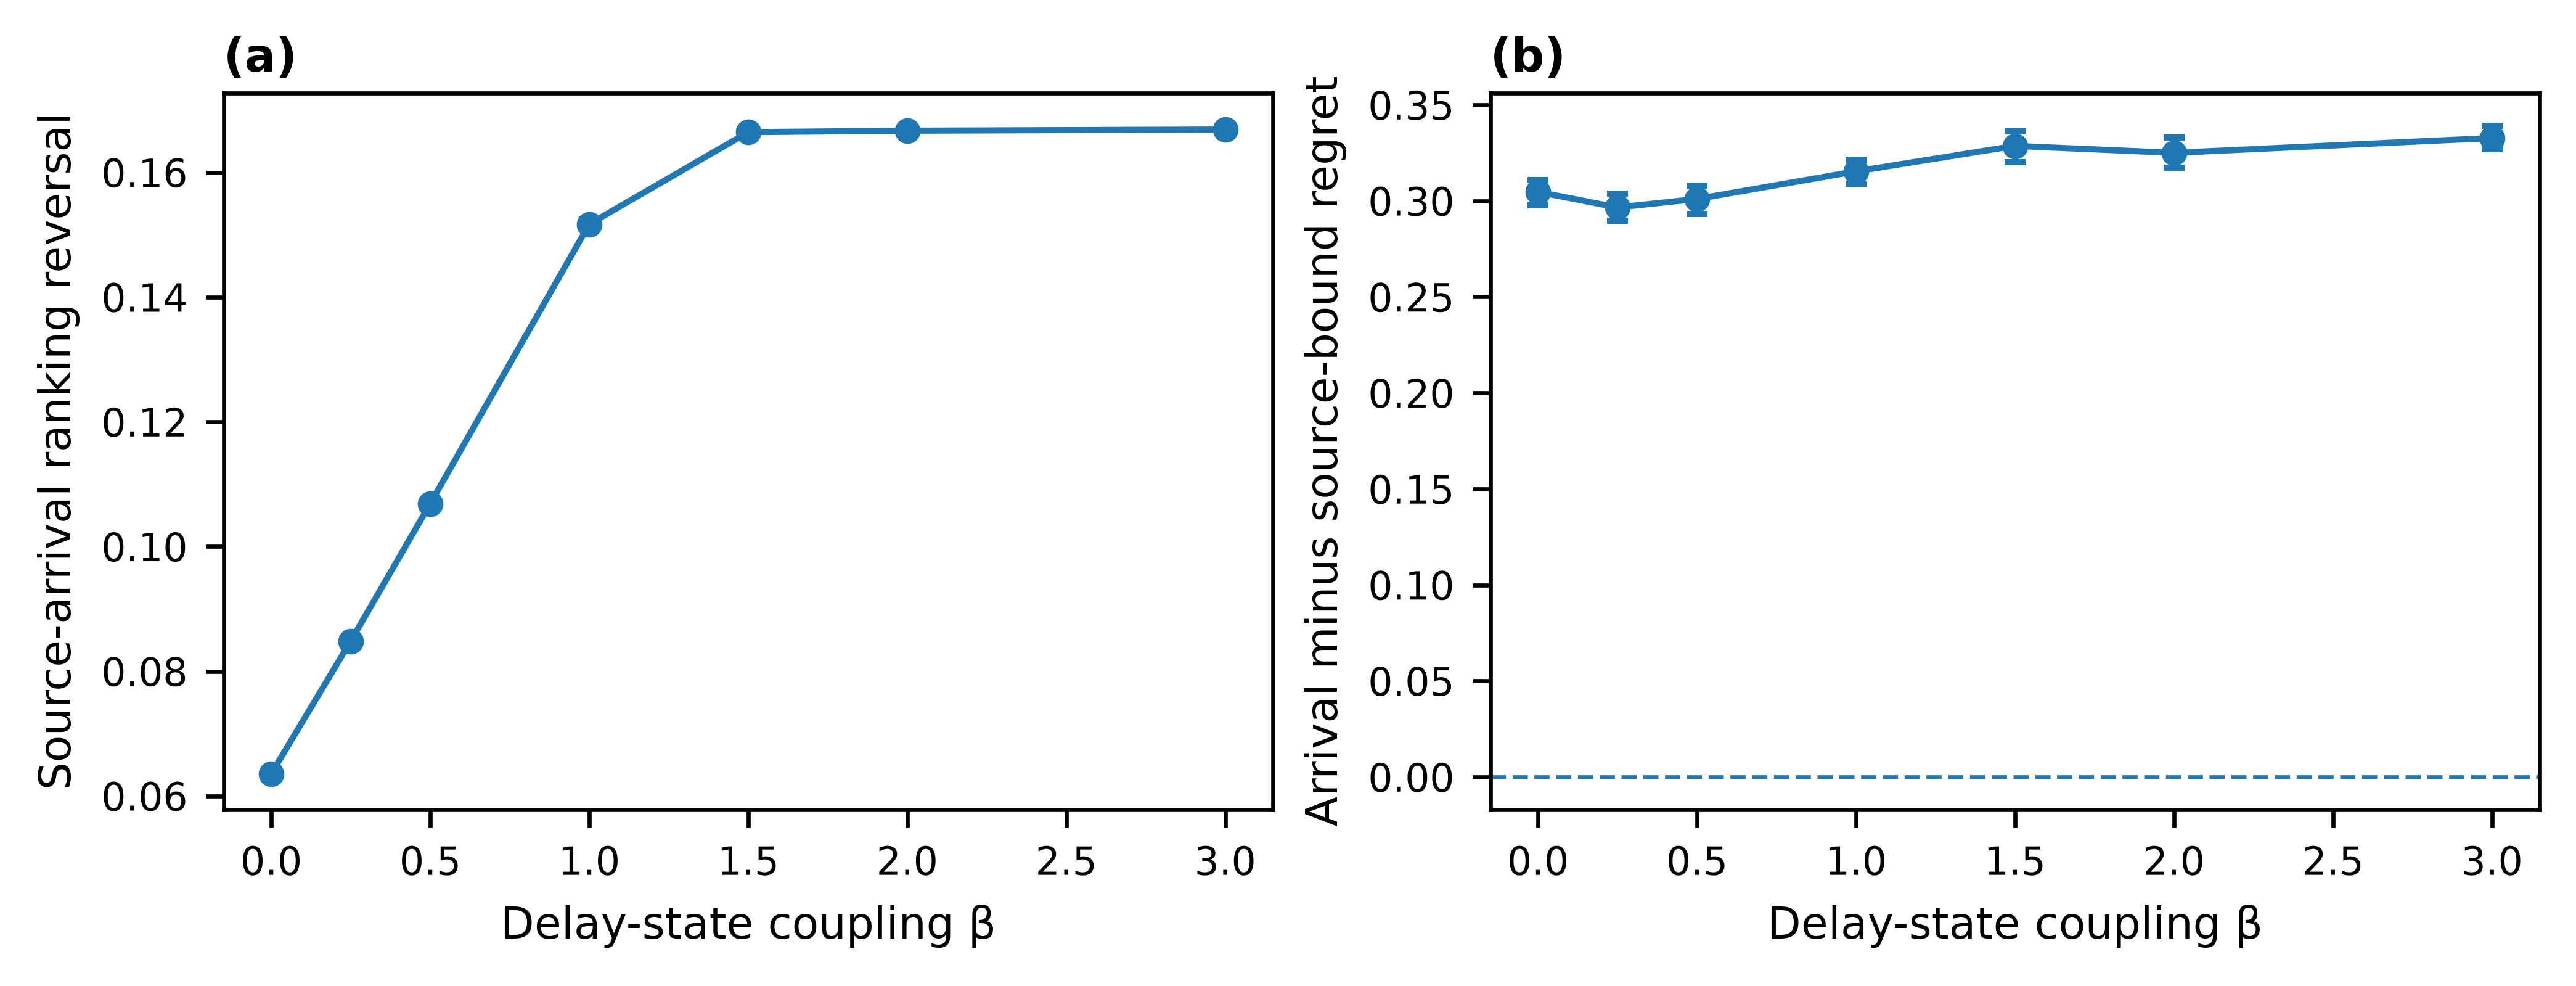

**outputs/runs/full_20260624T060105Z_02caa92e/figures/png/fig_exp4_recoverability_boundary.png**

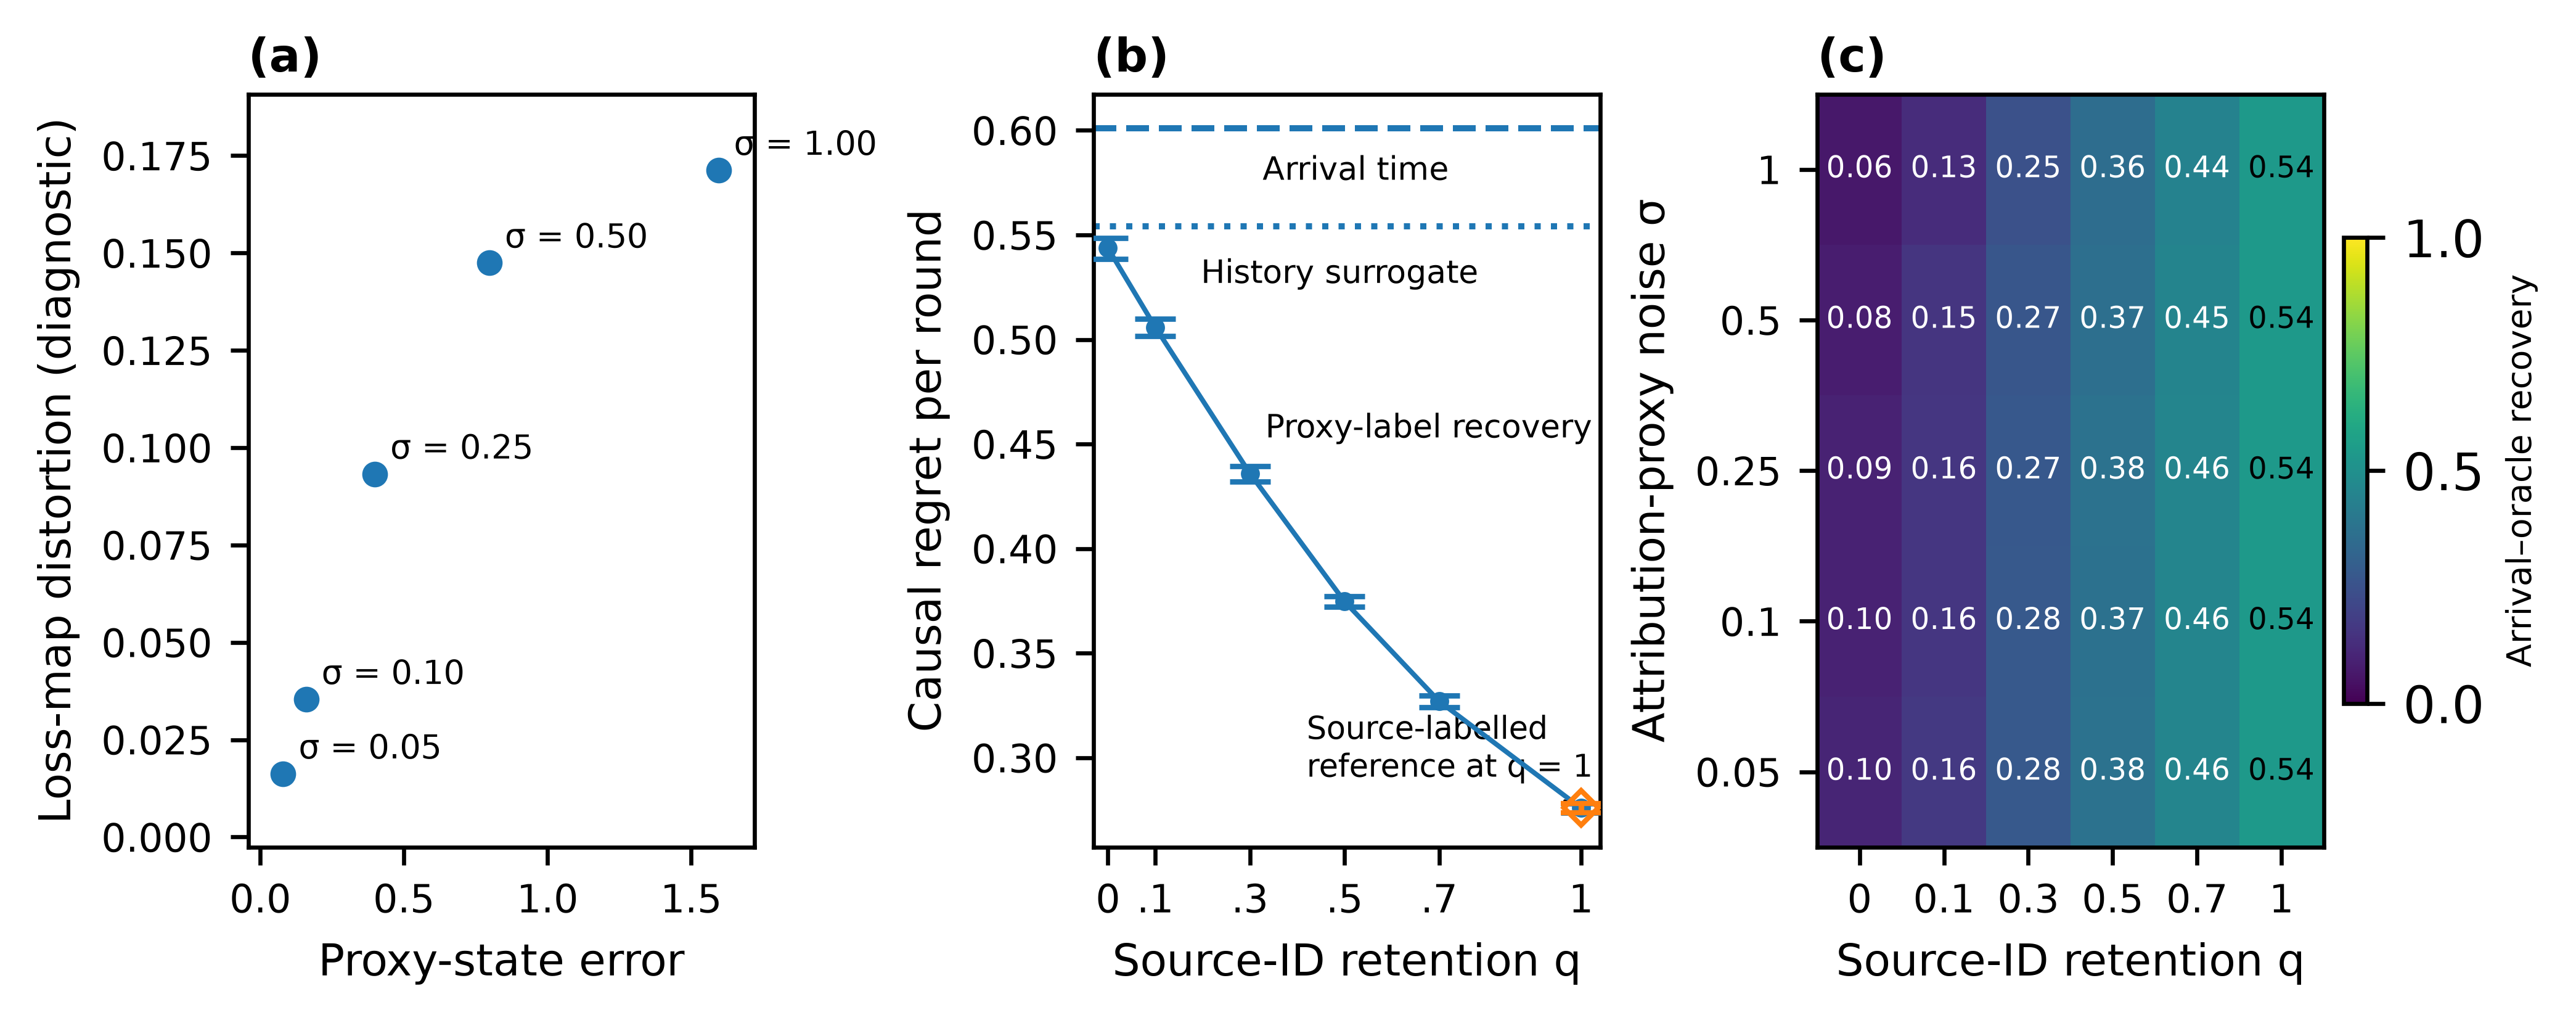

In [8]:
figures = prefer_outputs(find_files(['outputs/**/figures/**/*.png']))
display(Markdown(f'Found `{len(figures)}` PNG figure files. Showing selected embedded figures.'))
show_images(figures, limit=4)

In [9]:
logs = find_files(['runlogs/*', 'outputs/**/logs/*', '*.log', 'outputs/**/checks/*'])
log_rows = [{'path': rel(p), 'size_kb': round(p.stat().st_size / 1024, 1)} for p in logs[:30]]

display(Markdown(f'Found `{len(logs)}` runlog/check records.'))
display(pd.DataFrame(log_rows))
if not csvs:
    display(Markdown('Warning: no summary/table CSV detected under outputs/.'))
if not figures:
    display(Markdown('Warning: no figure PNG detected under outputs/.'))
display(Markdown('This notebook only reads existing outputs; no experiment entrypoint was executed.'))

Found `10` runlog/check records.

,path,size_kb
0,outputs/runs/full_20260624T060105Z_02caa92e/ch...,1.1
1,outputs/runs/full_20260624T060105Z_02caa92e/ch...,3.1
2,outputs/runs/full_20260624T060105Z_02caa92e/lo...,4.4
3,outputs/runs/full_20260624T060105Z_02caa92e/lo...,7.0
4,outputs/runs/full_20260624T060105Z_02caa92e/lo...,2.1
5,runlogs/exp4_code_check_20260624_135724.log,0.8
6,runlogs/exp4_fast_20260624_135724.log,0.1
7,runlogs/exp4_fast_20260624_135848.log,8.2
8,runlogs/exp4_fast_20260624_140020.log,6.8
9,runlogs/exp4_full_20260624_140105.log,62.5


This notebook only reads existing outputs; no experiment entrypoint was executed.